# Oxford-Pets-IIT: Feature Extraction and Analysis

## Introduction
This notebook implements an end-to-end machine learning pipeline for the **Oxford Pets IIT** dataset. The objective is to utilize Deep Neural Networks (DNNs) to extract high-level feature representations from images and analyze them using both unsupervised and supervised techniques.

We utilize a pre-trained **ResNet50** architecture to transform raw images into feature vectors, followed by dimensionality reduction and analysis.

## 📋 Table of Contents

1. **Exploratory Data Analysis (EDA)**
   - Inspecting sample images from the dataset.

2. **Feature Vector Extraction**
   - Loading the pre-trained **ResNet50** model.
   - Extracting 2048-dimensional embeddings for each image.

3. **Data Pre-processing**
   - Normalization and Standardization of feature vectors.
   - Dimensionality Reduction using **PCA** (Principal Component Analysis).

4. **Clustering (Unsupervised Learning)**
   - Applying **K-Means** clustering on the latent feature space.
   - Evaluating cluster quality using Silhouette Scores and Davies-Bouldin Index.

5. **Classification (Supervised Learning)**
   - Training a **Support Vector Machine (SVM)** on the extracted features.
   - Training a **Linear Classifier** (Fine-tuning).
   - Evaluating performance using Accuracy, Precision, Recall, and F1-Score.

---

### Imports

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import cv2
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import v2
from torchvision.models import resnet50, ResNet50_Weights
from torchvision.io import decode_image, ImageReadMode
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Getting the Data

In [3]:
path = "/content/drive/MyDrive/SCC-451/pets/images/images"


# Dataset Exploration

In [4]:
valid_ext = {".jpg", ".jpeg", ".png", ".bmp"}

images = []
labels = []

for file in os.listdir(path):
    if file.startswith('.'):
        continue  # skip hidden files
    ext = os.path.splitext(file)[1].lower()
    if ext in valid_ext:
        images.append(file)
        # Extract label before the last underscore
        label = '_'.join(file.split('_')[:-1])
        labels.append(label)

# Optional: create a dataframe
import pandas as pd
image_df = pd.DataFrame({
    'Images': images,
    'Labels': labels
})

In [5]:
print("shape =", image_df.shape)


shape = (7390, 2)


## Random Images Display

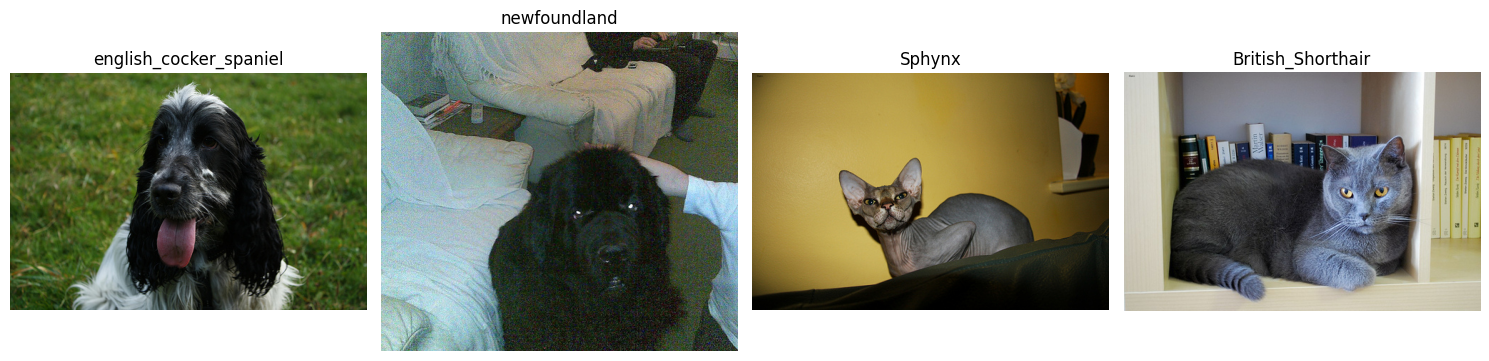

In [6]:
save_path = "/content/drive/MyDrive/SCC-451/plots"
os.makedirs(save_path, exist_ok=True)

# Number of random images to sample
num_samples = 4  # you can change this
sampled_rows = image_df.sample(n=num_samples, random_state=42)  # random sample

fig, axes = plt.subplots(1, num_samples, figsize=(15, 5))

for i, (_, row) in enumerate(sampled_rows.iterrows()):
    img_path = os.path.join(path, row['Images'])
    img = cv2.imread(img_path)
    if img is None:
        continue

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Save image
    out_name = f"sample_{i+1}_{row['Labels']}.png"
    cv2.imwrite(os.path.join(save_path, out_name), cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR))

    # Plot
    axes[i].imshow(img_rgb)
    axes[i].set_title(f"{row['Labels']}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

# Feature Extraction using Resnet 50

In [7]:
# 1. Create a Custom Dataset Class
# This separates data loading from model inference, allowing PyTorch to parallelize it.
class ImageDataset(Dataset):
    def __init__(self, image_df, root_dir, transform=None):
        self.image_df = image_df
        self.root_dir = root_dir
        self.transform = transform

    def __len__(self):
        return len(self.image_df)

    def __getitem__(self, idx):
        row = self.image_df.iloc[idx]
        img_name = row['Images']
        label = row['Labels']
        img_path = os.path.join(self.root_dir ,img_name)

        try:
            # Load Image
            img = decode_image(img_path, mode=ImageReadMode.RGB)

            # Apply Transforms
            if self.transform:
                img = self.transform(img)

            return img, label, img_name # Return name to track errors if needed

        except Exception as e:
            # Handle corrupted images gracefully (return None)
            print(f"Error loading {img_path}: {e}")
            return None, None, None

# Custom collate function to filter out bad images (None) from a batch
def collate_fn(batch):
    batch = list(filter(lambda x: x[0] is not None, batch))
    if not batch:
        return torch.tensor([]), [], []
    return torch.utils.data.dataloader.default_collate(batch)


# 2. Optimized Feature Extraction Class
class FeatureExtractor:
    def __init__(self, path: str, image_df: pd.DataFrame) -> None:
        self.path = path
        self.image_df = image_df
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        print(f"Running on: {self.device}")

        # Load Model
        self.weights = ResNet50_Weights.DEFAULT
        self.resnet_transforms = self.weights.transforms()
        self.model = resnet50(weights=self.weights)
        self.model.fc = torch.nn.Identity() # Remove classification head
        self.model.eval()
        self.model.to(self.device)

    def extract_features(self, batch_size=64, num_workers=4):
        # Setup Dataset and DataLoader
        dataset = ImageDataset(self.image_df, self.path, transform=self.resnet_transforms)

        # DataLoader handles the parallel loading and batching
        loader = DataLoader(
            dataset,
            batch_size=batch_size,
            shuffle=False,
            num_workers=num_workers, # Critical for speed! Uses CPU cores to load data
            pin_memory=True,         # Critical for speed! Faster CPU->GPU transfer
            collate_fn=collate_fn    # Skips corrupted images
        )

        all_features = []
        all_labels = []

        print(f"Starting feature extraction on {self.device} with batch_size={batch_size}...")

        with torch.no_grad():
            for batch_idx, (images, labels, names) in enumerate(loader):
                if images.numel() == 0: continue # Skip empty batches

                # Move batch to GPU
                images = images.to(self.device)

                # Inference (Extract features for 64 images at once)
                # Enable mixed precision for extra speed (optional, safe for inference)
                with torch.cuda.amp.autocast(enabled=(self.device.type == 'cuda')):
                    features = self.model(images)

                # Move results to CPU and store
                all_features.append(features.cpu().numpy())
                all_labels.extend(labels)

                if batch_idx % 10 == 0:
                    print(f"Processed batch {batch_idx}/{len(loader)}")

        # Concatenate all batches into one large array
        print("Concatenating results...")
        features_array = np.vstack(all_features)

        # Create DataFrame
        df_result = pd.DataFrame(features_array)
        df_result['Label'] = all_labels


        return df_result

## Image Subset Sampling
Since we have way too many images, we'll only take a subset and train of around 5000 images. We will split using stratify

In [8]:
from sklearn.model_selection import train_test_split

# Calculate the desired fraction for the subset
# We want approximately 5000 images out of 24959
subset_size = 3000
current_total_images = len(image_df)

if current_total_images > 0:
    # Ensure fraction is not more than 1
    subset_fraction = min(subset_size / current_total_images, 1.0)
else:
    print("Error: image_df is empty. Cannot create subset.")
    subset_fraction = 0.0 # Set to 0 to prevent further processing

if subset_fraction > 0:
    # Perform stratified split to maintain label proportions
    # We'll take the 'test' part as our subset
    _, image_df_subset = train_test_split(
        image_df,
        test_size=subset_fraction,
        stratify=image_df['Labels'],
        random_state=42
    )

    print(f"Original image_df shape: {image_df.shape}")
    print(f"Subset image_df_subset shape: {image_df_subset.shape}")
    print("Subset label counts:\n", image_df_subset['Labels'].value_counts())
else:
    image_df_subset = pd.DataFrame() # Create an empty DataFrame if no subset can be created


Original image_df shape: (7390, 2)
Subset image_df_subset shape: (3000, 2)
Subset label counts:
 Labels
Maine_Coon                    82
pomeranian                    82
Persian                       82
basset_hound                  82
german_shorthaired            82
yorkshire_terrier             82
english_setter                81
samoyed                       81
Birman                        81
Abyssinian                    81
wheaten_terrier               81
Egyptian_Mau                  81
english_cocker_spaniel        81
saint_bernard                 81
great_pyrenees                81
chihuahua                     81
havanese                      81
Sphynx                        81
japanese_chin                 81
pug                           81
Bengal                        81
leonberger                    81
Ragdoll                       81
keeshond                      81
shiba_inu                     81
Bombay                        81
beagle                        81
Briti

## Feature Extraction cell

In [9]:
extractor = FeatureExtractor(path= path,image_df = image_df_subset)
feature_vector_df = extractor.extract_features(batch_size=64, num_workers=4)

Running on: cuda
Starting feature extraction on cuda with batch_size=64...


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
/tmp/ipython-input-4120188003.py:85: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(self.device.type == 'cuda')):


Processed batch 0/47
Processed batch 10/47
Processed batch 20/47
Processed batch 30/47
Processed batch 40/47
Concatenating results...


In [10]:
print(feature_vector_df.shape)
feature_vector_df.describe()

(3000, 2049)


,0,1,2,3,4,5,6,7,8,9,...,2038,2039,2040,2041,2042,2043,2044,2045,2046,2047
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,...,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,0.027649,0.006840,0.023712,0.011948,0.079834,0.102356,0.106445,0.013145,0.014465,0.068726,...,0.069153,0.032715,0.016144,0.011406,0.243652,0.026306,0.020905,0.021011,0.014771,0.027924
std,0.082336,0.029968,0.079773,0.077942,0.161865,0.286621,0.197388,0.044800,0.064209,0.173096,...,0.254150,0.092346,0.068115,0.063904,0.702637,0.083130,0.082764,0.054352,0.059967,0.112732
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.011978,0.000000,0.014313,0.000000,0.000000,0.000478,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.015038,0.000000,0.010912,0.000000,0.089874,0.047981,0.121750,0.001209,0.000000,0.057327,...,0.023361,0.023510,0.000000,0.000000,0.095596,0.013973,0.001141,0.013241,0.000000,0.009577
max,1.569336,0.585449,1.328125,2.095703,2.097656,3.373047,2.062500,0.780273,1.158203,2.097656,...,3.185547,1.709961,1.373047,1.629883,6.960938,2.087891,2.253906,0.654785,1.569336,2.654297


# Pre-Processing

In [11]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [12]:
# Separate features and labels
X = feature_vector_df.drop('Label', axis=1).copy()
y = feature_vector_df['Label'].copy()

# Initialize StandardScaler
scaler = StandardScaler()

# Apply standard scaling to the features
X_scaled = scaler.fit_transform(X)

# Create a new DataFrame for scaled features
feature_vector_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

# Add the labels back to the scaled DataFrame
feature_vector_scaled_df['Label'] = y.reset_index(drop=True)

print("Shape of scaled feature vector DataFrame:", feature_vector_scaled_df.shape)
print("First 5 rows of scaled feature vector DataFrame (features and label):")
feature_vector_scaled_df.head()


Shape of scaled feature vector DataFrame: (3000, 2049)
First 5 rows of scaled feature vector DataFrame (features and label):


/usr/local/lib/python3.12/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.12/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,0,1,2,3,4,5,6,7,8,9,...,2039,2040,2041,2042,2043,2044,2045,2046,2047,Label
0,-0.027588,-0.228149,-0.297119,-0.15332,0.284180,-0.357178,1.327148,-0.293457,-0.225464,11.132812,...,-0.179443,-0.237061,-0.178467,-0.346924,-0.316650,-0.252686,-0.304932,-0.24646,-0.150879,Maine_Coon
1,1.192383,-0.228149,-0.297119,-0.15332,-0.493164,-0.357178,0.549316,-0.293457,-0.225464,-0.153687,...,-0.207764,-0.237061,-0.178467,-0.326660,-0.316650,-0.252686,-0.386719,-0.24646,0.020706,samoyed
2,1.395508,-0.228149,4.777344,-0.15332,7.902344,-0.276611,-0.159302,-0.293457,-0.225464,-0.086426,...,-0.354248,0.019287,-0.038971,-0.346924,1.325195,-0.252686,-0.244263,-0.24646,-0.199097,Birman
3,-0.335693,-0.228149,-0.297119,-0.15332,-0.493164,0.492676,-0.054504,-0.293457,0.600586,-0.397217,...,-0.354248,-0.237061,-0.178467,1.808594,-0.316650,-0.252686,-0.386719,-0.24646,-0.247681,english_setter
4,-0.335693,-0.228149,-0.297119,-0.15332,-0.454346,-0.357178,-0.539062,-0.293457,-0.225464,-0.397217,...,-0.354248,-0.237061,-0.178467,-0.346924,-0.090820,-0.252686,-0.386719,-0.24646,-0.247681,pomeranian


## PCA decomposition

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Fit PCA
max_components = 1000
pca = PCA(n_components=max_components)
pca.fit(feature_vector_scaled_df.drop('Label', axis=1))

PCA(n_components=1000)

In [14]:
print(np.sum(pca.explained_variance_ratio_[:100]))

0.4529618505128309


In [15]:
pca_100 = PCA(n_components=100)
X_pca_100 = pca_100.fit_transform(feature_vector_scaled_df.drop('Label', axis=1))

# Create a DataFrame for the 100 PCA results
pca_df_100 = pd.DataFrame(data=X_pca_100)
pca_df_100['Label'] = feature_vector_scaled_df['Label'].reset_index(drop=True)

print("Shape of PCA-reduced DataFrame (100 dimensions):", pca_df_100.shape)
print("First 5 rows of PCA-reduced DataFrame:")


Shape of PCA-reduced DataFrame (100 dimensions): (3000, 101)
First 5 rows of PCA-reduced DataFrame:


### Saving PCA
We save the PCA to re-use in the future since the feature extraction takes time to run

In [16]:
save_path ="/content/drive/MyDrive/SCC-451/dataset2_reduced_df.csv"

In [17]:
pca_df_100.to_csv(save_path)

## Visualization in 2D

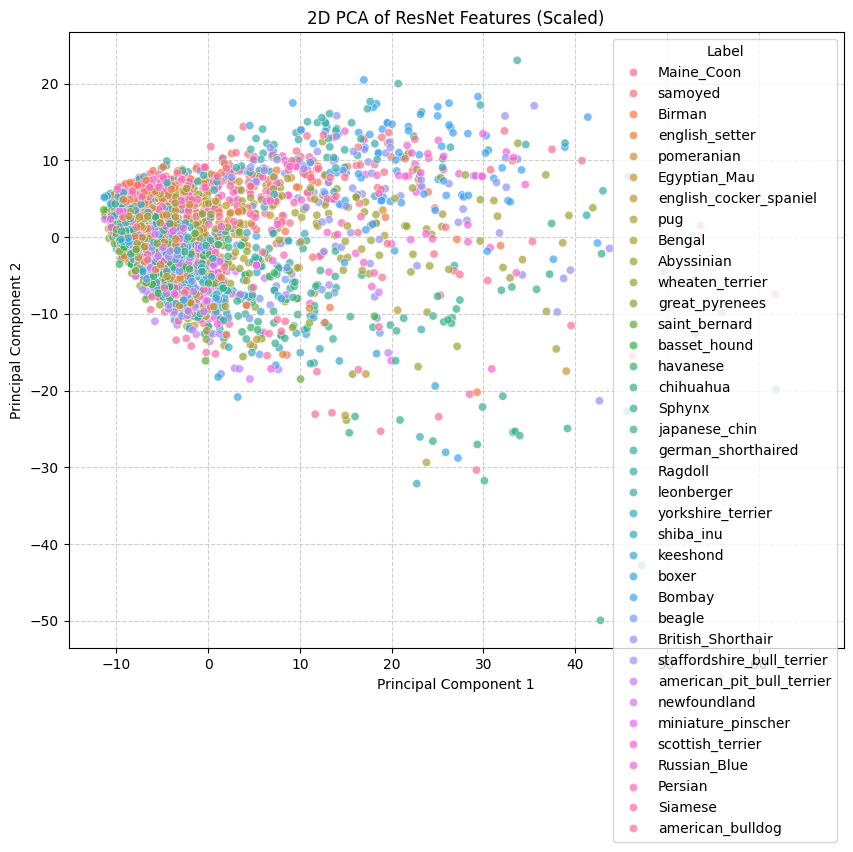

In [19]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(feature_vector_scaled_df.drop('Label', axis=1))

# Create a DataFrame for the 2D PCA results
pca_df = pd.DataFrame(data=X_pca, columns=['Principal Component 1', 'Principal Component 2'])
pca_df['Label'] = feature_vector_scaled_df['Label'].reset_index(drop=True)

# Plotting
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='Principal Component 1',
    y='Principal Component 2',
    hue='Label',
    data=pca_df,
    alpha=0.7
)
plt.title('2D PCA of ResNet Features (Scaled)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


# Clustering

## Mapping classes for Clustering

In [22]:
cluster_df = pd.read_csv(save_path)
cluster_df.shape

(3000, 102)

In [23]:
# Define dog and cat breeds
dog_breeds = [
    "American Bulldog", "American Pit Bull Terrier", "Basset Hound", "Beagle",
    "Boxer", "Chihuahua", "English Cocker Spaniel", "English Setter",
    "German Shorthaired", "Great Pyrenees", "Havanese", "Japanese Chin",
    "Keeshond", "Leonberger", "Miniature Pinscher", "Newfoundland",
    "Pomeranian", "Pug", "Saint Bernard", "Samoyed", "Scottish Terrier",
    "Shiba Inu", "Staffordshire Bull Terrier", "Wheaten Terrier", "Yorkshire Terrier"
]

cat_breeds = [
    "Abyssinian", "Bengal", "Birman", "Bombay", "British Shorthair",
    "Egyptian Mau", "Maine Coon", "Persian", "Ragdoll", "Russian Blue",
    "Siamese", "Sphynx"
]

# Create mapping dict
breed_to_family = {breed.lower().replace(" ", "_"): "Dog" for breed in dog_breeds}
breed_to_family.update({breed.lower().replace(" ", "_"): "Cat" for breed in cat_breeds})

# Map labels directly
cluster_df['cluster_label'] = cluster_df['Label'].apply(
    lambda x: breed_to_family.get(x.lower(), "Unknown")
)

# Check result
print(cluster_df[['Label', 'cluster_label']].head())

            Label cluster_label
0      Maine_Coon           Cat
1         samoyed           Dog
2          Birman           Cat
3  english_setter           Dog
4      pomeranian           Dog


In [24]:
cluster_df = cluster_df.drop(columns ='Label')

## Clustering with 100 PC's

In [25]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score,davies_bouldin_score

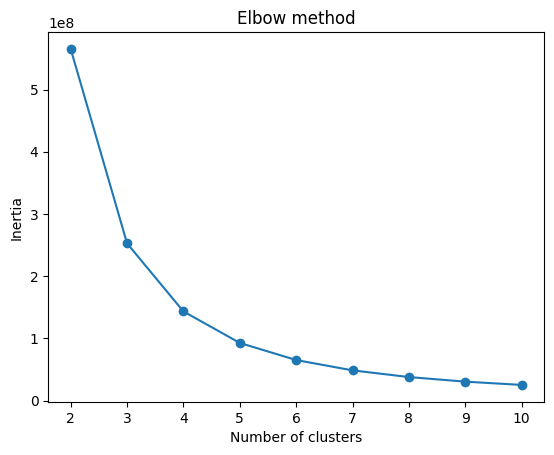

In [26]:
inertias = []
sil_score =[]
db_score =[]
results = []
xcluster_df = cluster_df.iloc[:,:-1]
for i in range(2,11):
    kmeans = KMeans(n_clusters=i,random_state=42)
    kmeans.fit(xcluster_df)
    score = silhouette_score(xcluster_df,kmeans.labels_)
    db_index = davies_bouldin_score(xcluster_df, kmeans.labels_)
    inertias.append(kmeans.inertia_)
    sil_score.append(score)
    db_score.append(db_index)
    results.append({
        "n_clusters": i,
        "inertia": kmeans.inertia_,
        "silhouette": silhouette_score(xcluster_df, kmeans.labels_),
        "davies_bouldin": davies_bouldin_score(xcluster_df, kmeans.labels_)
    })
results_df = pd.DataFrame(results)
plt.plot(range(2,11), inertias, marker='o')
plt.title('Elbow method')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show()

In [27]:
results_df

,n_clusters,inertia,silhouette,davies_bouldin
0,2,5.652786e+08,0.623671,0.503367
1,3,2.527771e+08,0.583955,0.506800
2,4,1.434059e+08,0.561760,0.511584
3,5,9.278037e+07,0.546341,0.516725
4,6,6.528216e+07,0.534139,0.522590
5,7,4.870077e+07,0.523635,0.528722
6,8,3.793803e+07,0.514380,0.536320
7,9,3.056282e+07,0.505491,0.544019
8,10,2.528983e+07,0.496879,0.553110


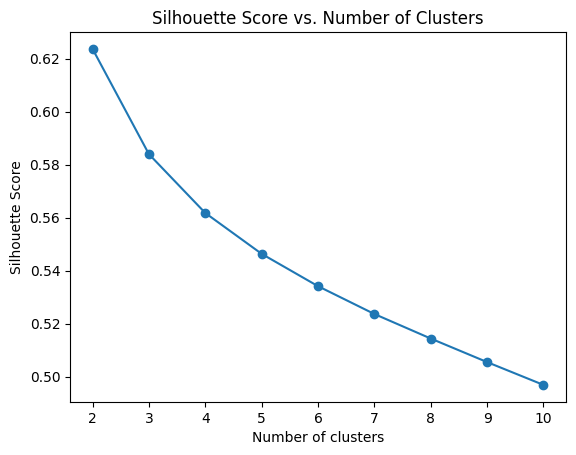

In [28]:
plt.plot(range(2,11), sil_score, marker='o')
plt.title('Silhouette Score vs. Number of Clusters')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.show()

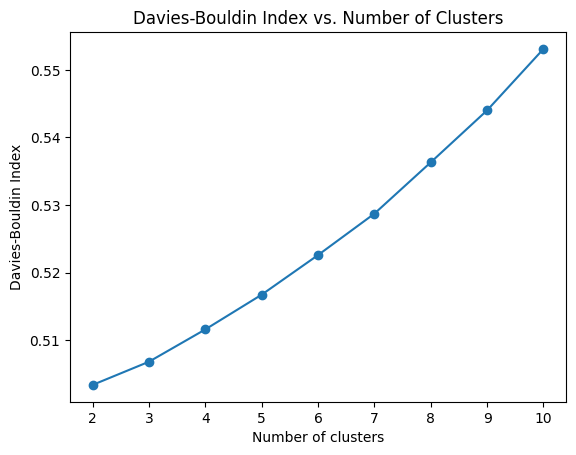

In [29]:
plt.plot(range(2,11), db_score, marker='o')
plt.title('Davies-Bouldin Index vs. Number of Clusters')
plt.xlabel('Number of clusters')
plt.ylabel('Davies-Bouldin Index')
plt.show()

## Clustering with 50 PC's

(3000, 50)


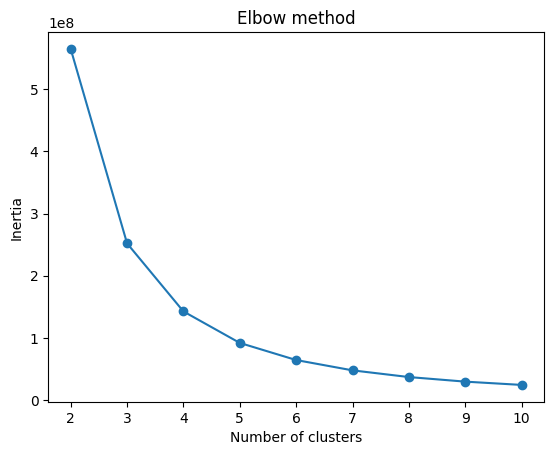

In [30]:
inertias = []
sil_score =[]
db_score =[]
results = []
xcluster_df = cluster_df.iloc[:,:50]
print(xcluster_df.shape)
for i in range(2,11):
    kmeans = KMeans(n_clusters=i,random_state=42)
    kmeans.fit(xcluster_df)
    score = silhouette_score(xcluster_df,kmeans.labels_)
    db_index = davies_bouldin_score(xcluster_df, kmeans.labels_)
    inertias.append(kmeans.inertia_)
    sil_score.append(score)
    db_score.append(db_index)
    results.append({
        "n_clusters": i,
        "inertia": kmeans.inertia_,
        "silhouette": silhouette_score(xcluster_df, kmeans.labels_),
        "davies_bouldin": davies_bouldin_score(xcluster_df, kmeans.labels_)
    })
results_df = pd.DataFrame(results)
plt.plot(range(2,11), inertias, marker='o')
plt.title('Elbow method')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show()

In [31]:
results_df

,n_clusters,inertia,silhouette,davies_bouldin
0,2,5.645934e+08,0.624269,0.502634
1,3,2.520921e+08,0.585165,0.505350
2,4,1.427211e+08,0.563714,0.509173
3,5,9.209607e+07,0.549101,0.513225
4,6,6.459768e+07,0.537792,0.517906
5,7,4.801840e+07,0.528229,0.522823
6,8,3.725399e+07,0.519896,0.528826
7,9,2.988773e+07,0.511905,0.535190
8,10,2.460649e+07,0.504380,0.542358


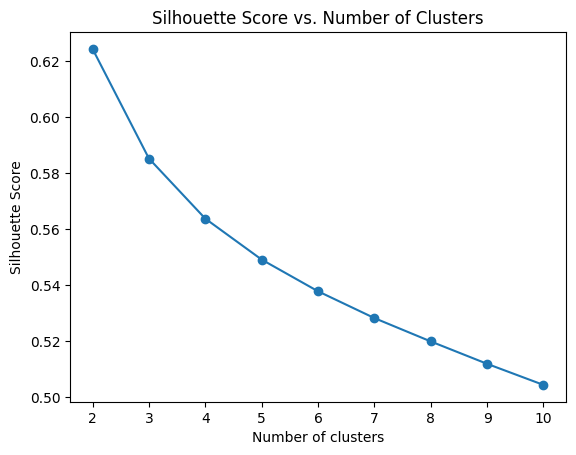

In [32]:
plt.plot(range(2,11), sil_score, marker='o')
plt.title('Silhouette Score vs. Number of Clusters')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.show()

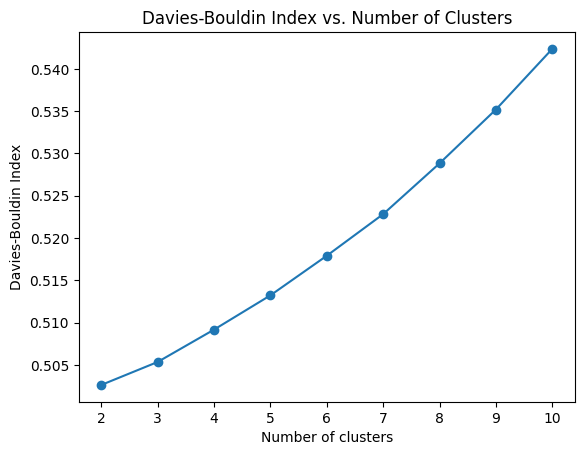

In [33]:
plt.plot(range(2,11), db_score, marker='o')
plt.title('Davies-Bouldin Index vs. Number of Clusters')
plt.xlabel('Number of clusters')
plt.ylabel('Davies-Bouldin Index')
plt.show()

## Clustering with 20 PC's

(3000, 20)


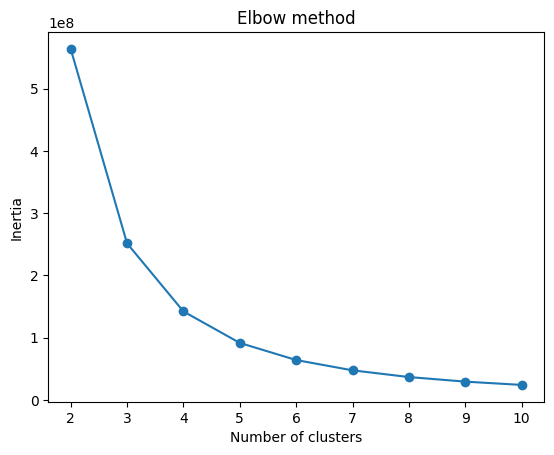

In [34]:
inertias = []
sil_score =[]
db_score =[]
results = []
xcluster_df = cluster_df.iloc[:,:20]
print(xcluster_df.shape)
for i in range(2,11):
    kmeans = KMeans(n_clusters=i,random_state=42)
    kmeans.fit(xcluster_df)
    score = silhouette_score(xcluster_df,kmeans.labels_)
    db_index = davies_bouldin_score(xcluster_df, kmeans.labels_)
    inertias.append(kmeans.inertia_)
    sil_score.append(score)
    db_score.append(db_index)
    results.append({
        "n_clusters": i,
        "inertia": kmeans.inertia_,
        "silhouette": silhouette_score(xcluster_df, kmeans.labels_),
        "davies_bouldin": davies_bouldin_score(xcluster_df, kmeans.labels_)
    })
results_df = pd.DataFrame(results)
plt.plot(range(2,11), inertias, marker='o')
plt.title('Elbow method')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show()

In [35]:
results_df

,n_clusters,inertia,silhouette,davies_bouldin
0,2,5.638819e+08,0.624944,0.501808
1,3,2.513894e+08,0.586550,0.503711
2,4,1.420232e+08,0.565967,0.506430
3,5,9.139951e+07,0.552327,0.509291
4,6,6.391276e+07,0.542133,0.512473
5,7,4.735562e+07,0.533651,0.516098
6,8,3.657084e+07,0.526443,0.520191
7,9,2.919321e+07,0.519743,0.524886
8,10,2.390909e+07,0.513469,0.530042


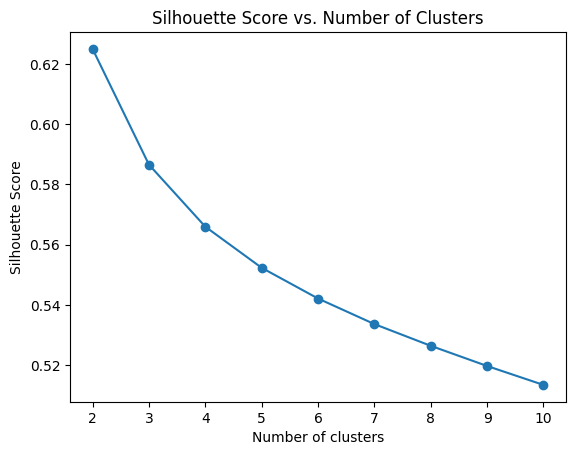

In [36]:
plt.plot(range(2,11), sil_score, marker='o')
plt.title('Silhouette Score vs. Number of Clusters')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.show()

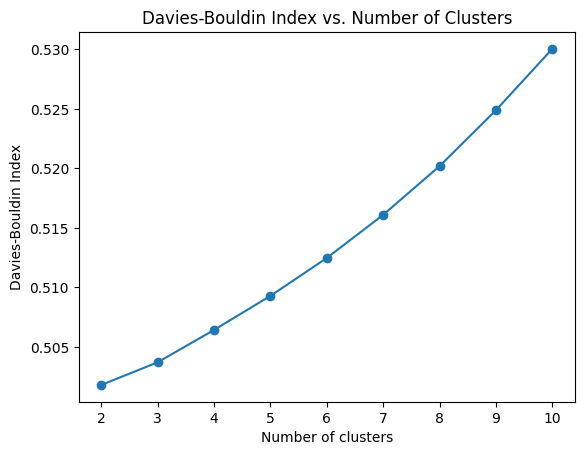

In [37]:
plt.plot(range(2,11), db_score, marker='o')
plt.title('Davies-Bouldin Index vs. Number of Clusters')
plt.xlabel('Number of clusters')
plt.ylabel('Davies-Bouldin Index')
plt.show()

## Cluster Visualization

In [38]:
cluster_df['cluster_label'].value_counts()


,count
cluster_label,
Dog,2026
Cat,974


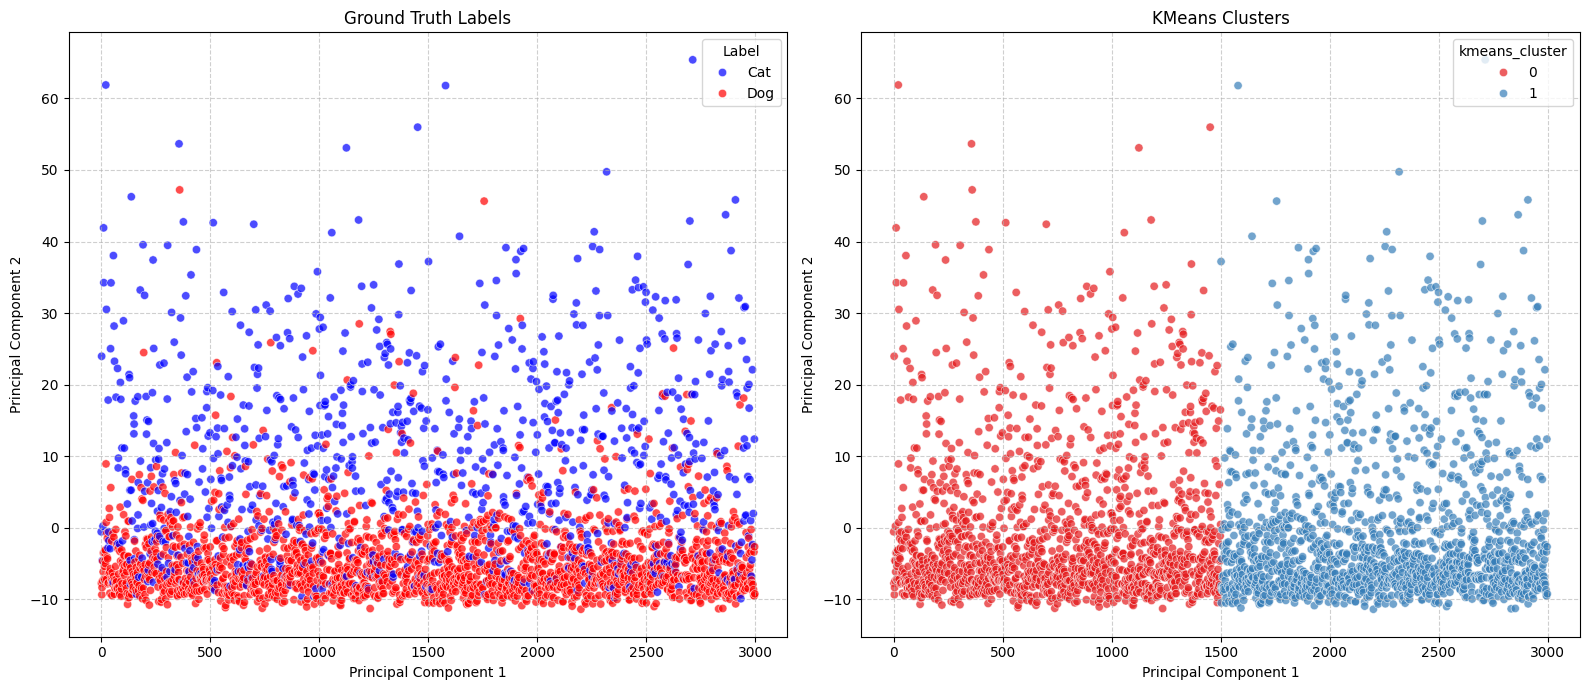

In [39]:
# Prepare small PCA DataFrame
pca_df = cluster_df.iloc[:, :2].copy()
pca_df.columns = ['Principal Component 1', 'Principal Component 2']
pca_df['Label'] = cluster_df['cluster_label'].values

# Fit KMeans
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
pca_df['kmeans_cluster'] = kmeans.fit_predict(pca_df[['Principal Component 1', 'Principal Component 2']])

# Plot side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Ground truth labels
sns.scatterplot(
    data=pca_df,
    x='Principal Component 1',
    y='Principal Component 2',
    hue='Label',
    palette={'Cat': 'blue', 'Dog': 'red'},
    alpha=0.7,
    ax=axes[0]
)
axes[0].set_title('Ground Truth Labels')
axes[0].grid(True, linestyle='--', alpha=0.6)

# KMeans clusters
sns.scatterplot(
    data=pca_df,
    x='Principal Component 1',
    y='Principal Component 2',
    hue='kmeans_cluster',
    palette='Set1',
    alpha=0.7,
    ax=axes[1]
)
axes[1].set_title('KMeans Clusters')
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


# Classification

## SVM with 100 PC's

Firstly using 100 features

In [40]:
classification_df = pd.read_csv(save_path)
classification_df.shape

(3000, 102)

In [41]:
X= classification_df.iloc[:,:-1]
y = classification_df.iloc[:,-1]

In [42]:
print(y.head())

0        Maine_Coon
1           samoyed
2            Birman
3    english_setter
4        pomeranian
Name: Label, dtype: object


In [43]:
print(X.head(2))

   Unnamed: 0         0         1         2         3         4         5  \
0           0 -0.553507  6.328247  1.681670  6.103266 -8.350806 -0.143889   
1           1 -7.741286  0.504676 -0.988736  5.927748  0.624163 -3.412388   

          6         7         8  ...        90        91        92        93  \
0 -2.051978 -1.322177  0.411079  ... -1.905712 -1.882151 -1.298977  0.943028   
1  7.957009  2.145082 -2.349460  ...  0.549650  0.679131  1.070412  0.222045   

         94        95        96        97        98        99  
0  0.551114 -3.591528 -0.689774 -1.457576  1.240965  0.624526  
1  1.364490  2.746729  0.375005 -0.898614 -0.202465 -0.768385  

[2 rows x 101 columns]


In [44]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [45]:
print("Training SVM...")
svm = SVC(kernel='rbf', C=1.0) # RBF kernel is standard for "feature" vectors
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)

Training SVM...


In [46]:
print("\n--- SVM Results ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_svm):.4f}")
print(classification_report(y_test, y_pred_svm))


--- SVM Results ---
Accuracy: 0.0283
                            precision    recall  f1-score   support

                Abyssinian       0.00      0.00      0.00        18
                    Bengal       0.00      0.00      0.00        24
                    Birman       0.00      0.00      0.00        14
                    Bombay       0.00      0.00      0.00        19
         British_Shorthair       0.00      0.00      0.00        17
              Egyptian_Mau       0.00      0.00      0.00        15
                Maine_Coon       0.03      0.24      0.05        17
                   Persian       0.09      0.17      0.12        18
                   Ragdoll       0.00      0.00      0.00        13
              Russian_Blue       0.00      0.00      0.00        20
                   Siamese       0.00      0.00      0.00        10
                    Sphynx       0.00      0.00      0.00        10
          american_bulldog       0.02      0.21      0.03        14
 american

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## SVM with 50 PC's

In [47]:
X= classification_df.iloc[:,:50]
y = classification_df.iloc[:,-1]

In [48]:
print(X.shape)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape)

(3000, 50)
(2400, 50)


In [49]:
print("Training SVM...")
svm = SVC(kernel='rbf', C=1.0) # RBF kernel is standard for "feature" vectors
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)

Training SVM...


In [50]:
print("\n--- SVM Results ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_svm):.4f}")
print(classification_report(y_test, y_pred_svm))


--- SVM Results ---
Accuracy: 0.0283
                            precision    recall  f1-score   support

                Abyssinian       0.00      0.00      0.00        18
                    Bengal       0.00      0.00      0.00        24
                    Birman       0.00      0.00      0.00        14
                    Bombay       0.00      0.00      0.00        19
         British_Shorthair       0.00      0.00      0.00        17
              Egyptian_Mau       0.00      0.00      0.00        15
                Maine_Coon       0.03      0.24      0.05        17
                   Persian       0.10      0.17      0.12        18
                   Ragdoll       0.00      0.00      0.00        13
              Russian_Blue       0.00      0.00      0.00        20
                   Siamese       0.00      0.00      0.00        10
                    Sphynx       0.00      0.00      0.00        10
          american_bulldog       0.02      0.21      0.03        14
 american

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## SVM with 20 PC's

In [51]:
X= classification_df.iloc[:,:20]
y = classification_df.iloc[:,-1]

In [52]:
print(X.shape)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

(3000, 20)


In [53]:
print("Training SVM...")
svm = SVC(kernel='rbf', C=1.0) # RBF kernel is standard for "feature" vectors
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)

Training SVM...


In [54]:
print("\n--- SVM Results ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_svm):.4f}")
print(classification_report(y_test, y_pred_svm))


--- SVM Results ---
Accuracy: 0.0283
                            precision    recall  f1-score   support

                Abyssinian       0.00      0.00      0.00        18
                    Bengal       0.00      0.00      0.00        24
                    Birman       0.00      0.00      0.00        14
                    Bombay       0.00      0.00      0.00        19
         British_Shorthair       0.00      0.00      0.00        17
              Egyptian_Mau       0.00      0.00      0.00        15
                Maine_Coon       0.03      0.24      0.05        17
                   Persian       0.12      0.17      0.14        18
                   Ragdoll       0.00      0.00      0.00        13
              Russian_Blue       0.00      0.00      0.00        20
                   Siamese       0.00      0.00      0.00        10
                    Sphynx       0.00      0.00      0.00        10
          american_bulldog       0.02      0.21      0.03        14
 american

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Using Linear Layer

In [55]:
from torch.utils.data import TensorDataset, DataLoader
from torch import nn
import torch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [56]:
# Features and labels
X = feature_vector_scaled_df.iloc[:, :-1].values.astype(float)
y = feature_vector_scaled_df.iloc[:, -1].values  # likely strings

# Convert string labels to integers
le = LabelEncoder()
y = le.fit_transform(y)  # now y is integer 0..num_classes-1

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Convert to torch tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test  = torch.tensor(X_test,  dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
y_test  = torch.tensor(y_test,  dtype=torch.long)

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")


X_train shape: torch.Size([2400, 2048]), y_train shape: torch.Size([2400])
X_test shape: torch.Size([600, 2048]), y_test shape: torch.Size([600])


In [57]:
train_ds = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)

### defining linear layer

In [58]:
num_features = 2048
num_classes = len(torch.unique(y_train))

linear_layer = nn.Linear(num_features, num_classes)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(linear_layer.parameters(), lr=1e-3)


### training linear layer

In [59]:
linear_layer.train()

loss_history = [] # Store loss for plotting

for epoch in range(20):
    total_loss = 0.0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        logits = linear_layer(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    loss_history.append(total_loss)
    print(f"Epoch {epoch+1}/20 - Loss: {total_loss:.4f}")


Epoch 1/20 - Loss: 59.4404
Epoch 2/20 - Loss: 8.3755
Epoch 3/20 - Loss: 4.0203
Epoch 4/20 - Loss: 2.5822
Epoch 5/20 - Loss: 1.8285
Epoch 6/20 - Loss: 1.3582
Epoch 7/20 - Loss: 1.0778
Epoch 8/20 - Loss: 0.8667
Epoch 9/20 - Loss: 0.7178
Epoch 10/20 - Loss: 0.6034
Epoch 11/20 - Loss: 0.5225
Epoch 12/20 - Loss: 0.4542
Epoch 13/20 - Loss: 0.3979
Epoch 14/20 - Loss: 0.3536
Epoch 15/20 - Loss: 0.3183
Epoch 16/20 - Loss: 0.2879
Epoch 17/20 - Loss: 0.2585
Epoch 18/20 - Loss: 0.2397
Epoch 19/20 - Loss: 0.2182
Epoch 20/20 - Loss: 0.1990


### training loss per epoch

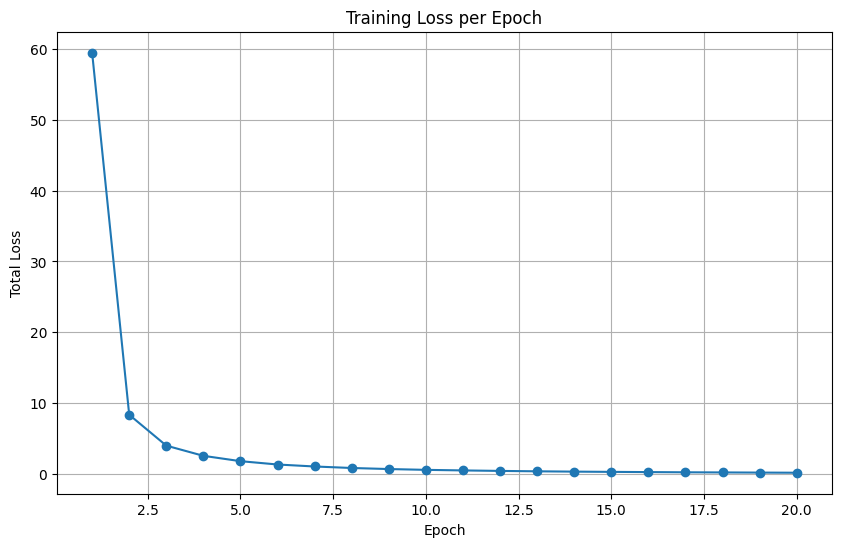

In [60]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(loss_history) + 1), loss_history, marker='o', linestyle='-')
plt.title('Training Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Total Loss')
plt.grid(True)
plt.show()


### evaluation

In [61]:
linear_layer.eval()
with torch.no_grad():
    logits = linear_layer(X_test)
    preds = torch.argmax(logits, dim=1)

accuracy = (preds == y_test).float().mean().item()
print(f"Test Accuracy: {accuracy:.4f}")


Test Accuracy: 0.9033


In [ ]:
# Detailed classification report per class
print("\nClassification Report:\n")
print(classification_report(y_test,preds))


Classification Report:

              precision    recall  f1-score   support

           0       0.76      1.00      0.86        16
           1       0.73      0.69      0.71        16
           2       0.75      0.75      0.75        16
           3       0.76      1.00      0.86        16
           4       0.69      0.69      0.69        16
           5       0.87      0.81      0.84        16
           6       0.88      0.88      0.88        17
           7       0.85      1.00      0.92        17
           8       0.73      0.65      0.69        17
           9       0.88      0.44      0.58        16
          10       0.88      0.88      0.88        16
          11       1.00      0.94      0.97        16
          12       0.76      1.00      0.86        16
          13       0.81      0.81      0.81        16
          14       0.94      0.94      0.94        17
          15       0.94      0.94      0.94        16
          16       1.00      0.88      0.93        16
  